## Principles of Machine Learning Final Project
**By: Saheli Ray, Wyatt Golden, HuiDi Hu**

In [64]:
# All imports needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = 100
        


In [65]:
# Quick environment check
%cd /home/jovyan/work
!ls

/home/jovyan/work
decision_tree_submission.csv  random_forest_submission.csv  test.csv
FinalProject.ipynb	      README.md			    train.csv


## Data Exploration / Cleaning
**In this section of the notebook, we inspect the dataset, choose a focused feature set, and standardize the data so the same preparation logic can be reused for both training and test predictions.**
        


In [66]:
# Load dataset and look at its shape and first 5 rows
train = pd.read_csv("train.csv", low_memory=False)
print("Dataset shape:", train.shape)
train.head(5)

Dataset shape: (307178, 55)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,NaN,B-727-200,148,11,34.0,10.0,A,4.0,D,3.0,5.0,6.0,5.0,NaN,Approach,300.0,145.0,NaN,Some Cloud,NaN,NaN,UNKBS,Unknown bird - small,0,NO SIGN OF BIRD ON A/C.,1,0,No,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,5293,MD-11,583,39,22.0,7.0,A,4.0,D,3.0,1.0,6.0,1.0,NaN,Approach,50.0,NaN,0.0,NaN,NaN,NaN,UNKBM,Unknown bird - medium,0,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,0,Unknown,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,907,A-300,04A,1,34.0,46.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Approach,3500.0,240.0,8.0,NaN,NaN,NaN,UNKBL,Unknown bird - large,0,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,0,No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NE120,Western gull,0,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,1,0,Unknown,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,NaN,B-737-200,148,13,34.0,10.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Landing Roll,0.0,135.0,0.0,Some Cloud,NaN,NaN,R1101,American barn owl,0,TIME 0824 LCL.,0,0,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


## Visual Data Exploration
The plots below summarize the structure of the dataset and give visual evidence for the feature choices and feature engineering used later in the notebook.

In particular, these charts are meant to show:
- the strong class imbalance in `INDICATED_DAMAGE`
- which candidate variables are missing often, and whether missingness itself may carry signal
- how damage rates change across flight phase, time-of-day, strike size, and month
- why variables such as `SPEED`, `HEIGHT`, and `DISTANCE` were kept, and why cyclical month features make sense


Target rate: 0.0636


,count
INDICATED_DAMAGE,
0,287651
1,19527


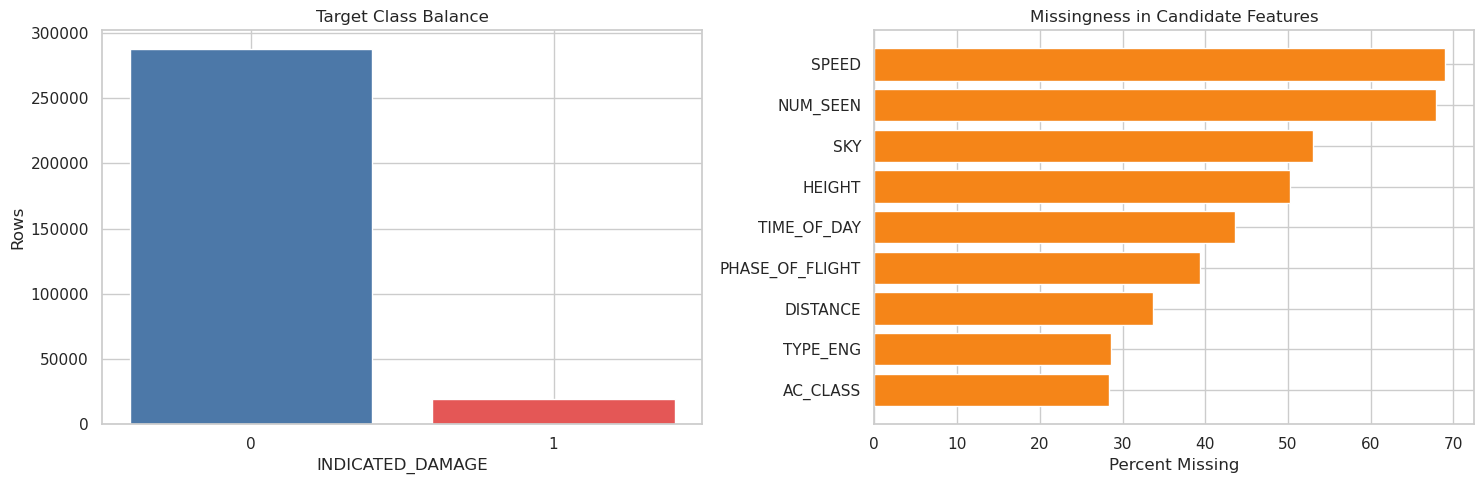

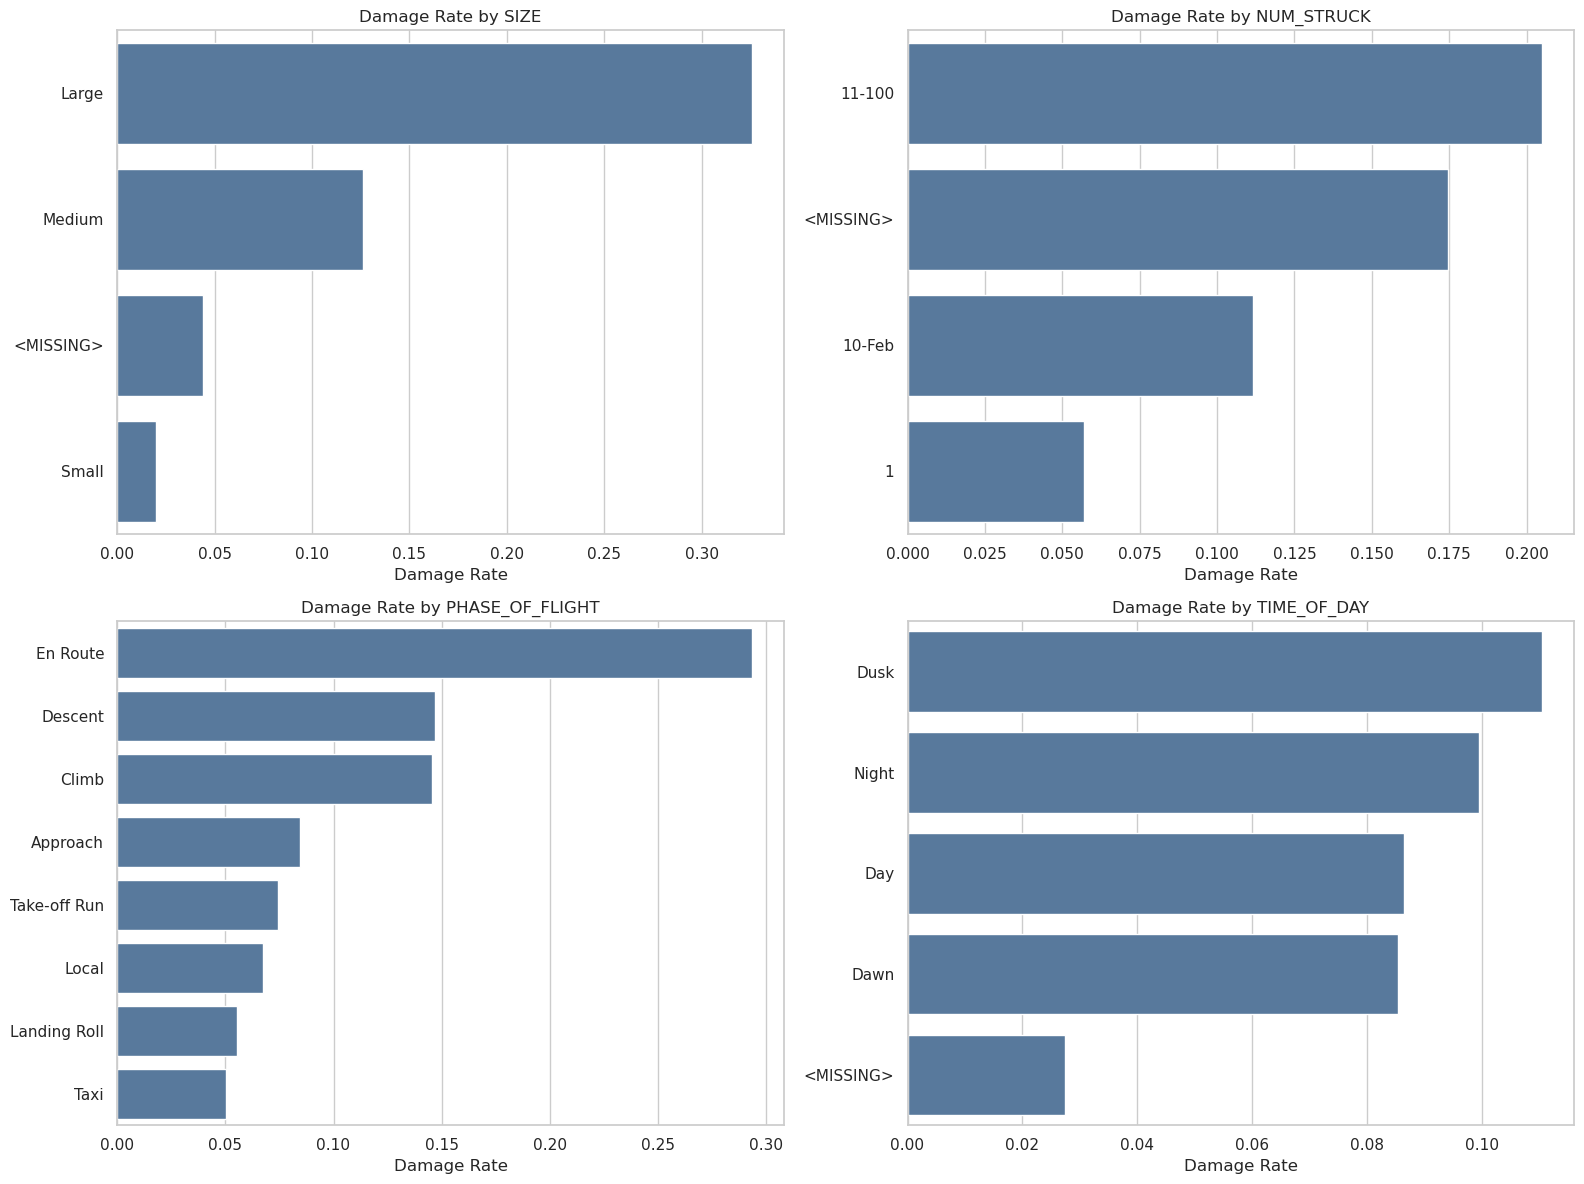

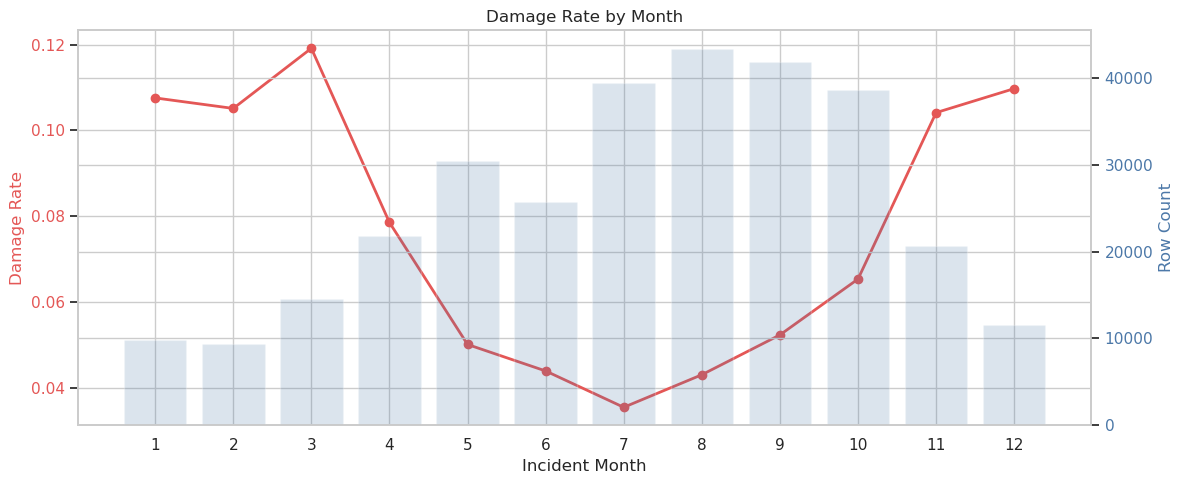

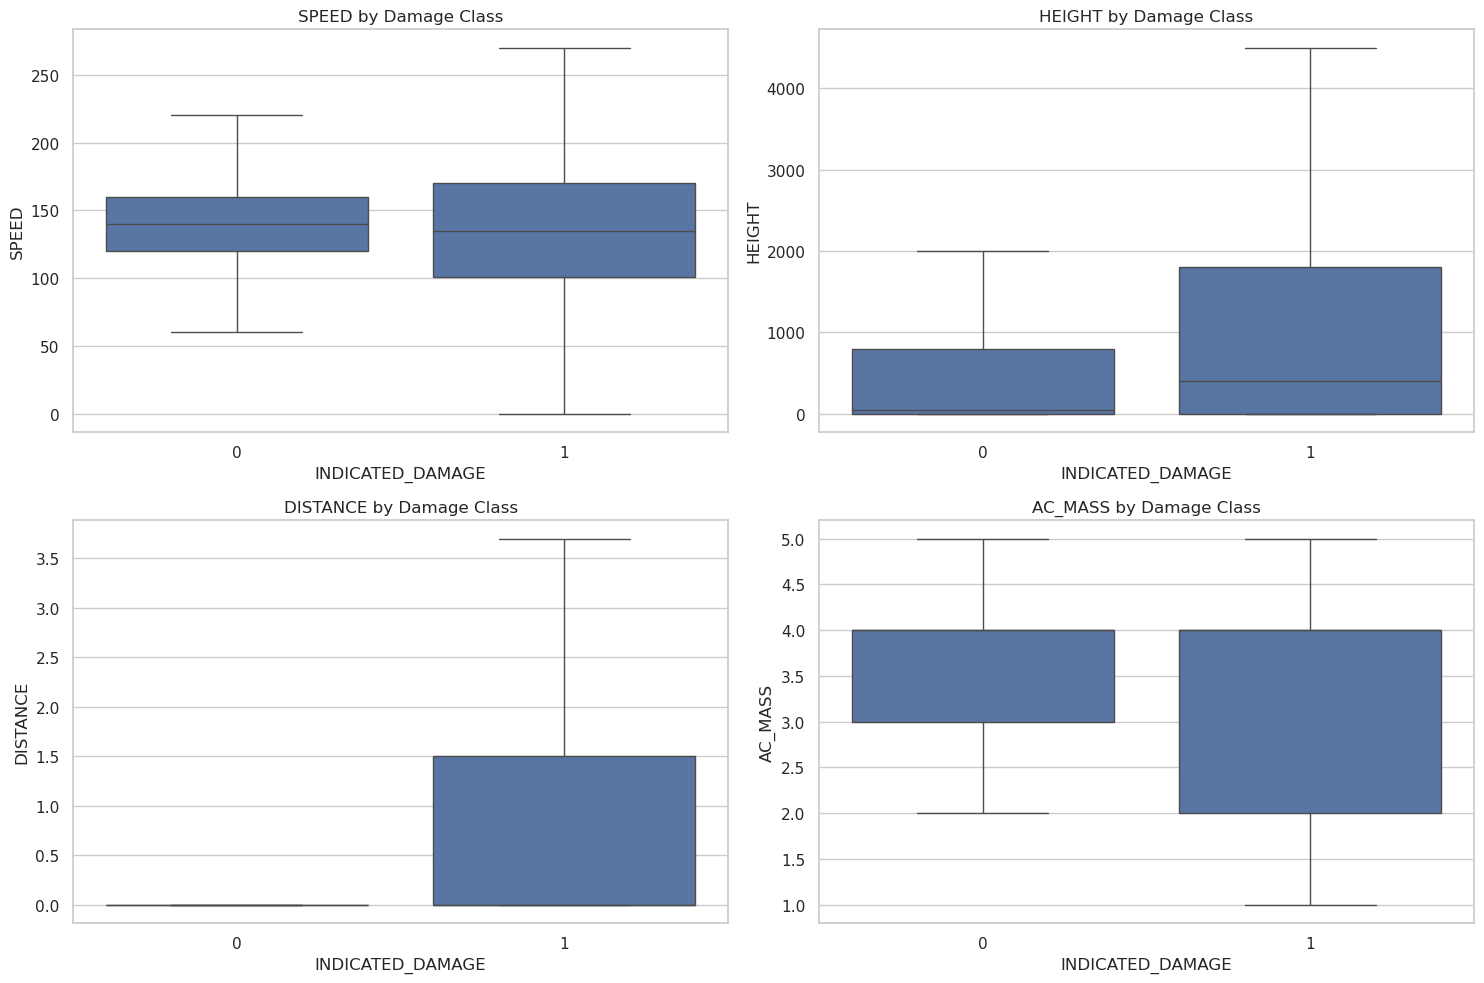

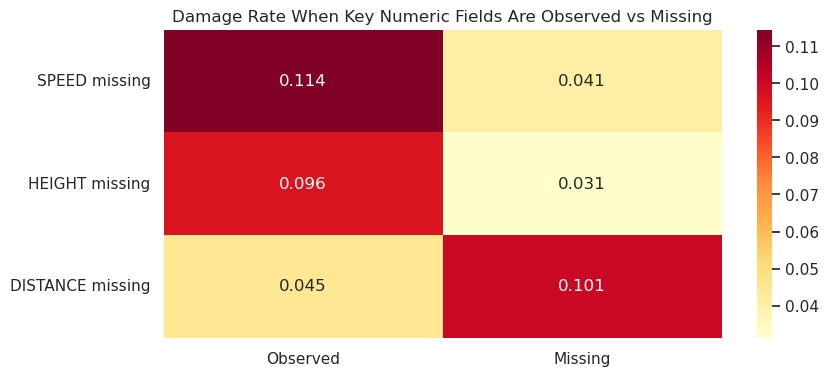

Key EDA takeaways
- The target is highly imbalanced, so balanced accuracy is the right metric to emphasize.
- Flight context variables such as PHASE_OF_FLIGHT, TIME_OF_DAY, SIZE, and NUM_STRUCK show visible differences in damage rate.
- SPEED, HEIGHT, DISTANCE, and AC_MASS show different numeric distributions for damage vs no-damage rows.
- Month-to-month variation supports keeping temporal context and motivates cyclical month features.
- Missingness in several numeric strike-condition fields appears non-random, which helps explain the missing-indicator features.


In [67]:
# Build a compact EDA view focused on feature choice and feature engineering decisions.
sns.set_theme(style="whitegrid")

eda_columns = [
    "INDICATED_DAMAGE", "LATITUDE", "LONGITUDE", "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
    "SPEED", "HEIGHT", "DISTANCE", "SPECIES_ID", "SIZE", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "INCIDENT_MONTH", "FAAREGION"
]

eda = train[eda_columns].copy()
for col in ["LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH"]:
    eda[col] = pd.to_numeric(eda[col], errors="coerce")
for col in ["AC_CLASS", "TYPE_ENG", "SPECIES_ID", "SIZE", "NUM_STRUCK", "NUM_SEEN", "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "FAAREGION"]:
    eda[col] = eda[col].replace(r"^\s*$", np.nan, regex=True)

print("Target rate:", round(eda["INDICATED_DAMAGE"].mean(), 4))
display(eda["INDICATED_DAMAGE"].value_counts().rename("count").to_frame())

# Plot 1: class balance and missingness in the main candidate columns.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

class_counts = eda["INDICATED_DAMAGE"].value_counts().sort_index()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=["#4C78A8", "#E45756"])
axes[0].set_title("Target Class Balance")
axes[0].set_xlabel("INDICATED_DAMAGE")
axes[0].set_ylabel("Rows")

missing_candidates = [
    "SPEED", "HEIGHT", "DISTANCE", "NUM_SEEN", "TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "TYPE_ENG", "AC_CLASS"
]
missing_rates = eda[missing_candidates].isna().mean().sort_values()
axes[1].barh(missing_rates.index, missing_rates.values * 100, color="#F58518")
axes[1].set_title("Missingness in Candidate Features")
axes[1].set_xlabel("Percent Missing")

plt.tight_layout()
plt.show()

# Plot 2: damage rate for key categorical variables we kept.
def damage_rate_table(column, min_count=300):
    summary = eda[[column, "INDICATED_DAMAGE"]].copy()
    summary[column] = summary[column].fillna("<MISSING>")
    summary = (
        summary.groupby(column)["INDICATED_DAMAGE"]
        .agg(["size", "mean"])
        .rename(columns={"size": "count", "mean": "damage_rate"})
        .sort_values(["damage_rate", "count"], ascending=[False, False])
    )
    return summary[summary["count"] >= min_count]

plot_columns = ["SIZE", "NUM_STRUCK", "PHASE_OF_FLIGHT", "TIME_OF_DAY"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, column in zip(axes.flat, plot_columns):
    summary = damage_rate_table(column).head(8)
    sns.barplot(data=summary.reset_index(), x="damage_rate", y=column, ax=ax, color="#4C78A8")
    ax.set_title(f"Damage Rate by {column}")
    ax.set_xlabel("Damage Rate")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Plot 3: month pattern to motivate cyclical month encoding.
month_damage = eda.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].mean()
month_counts = eda.groupby("INCIDENT_MONTH").size()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(month_damage.index, month_damage.values, marker="o", color="#E45756", linewidth=2)
ax1.set_title("Damage Rate by Month")
ax1.set_xlabel("Incident Month")
ax1.set_ylabel("Damage Rate", color="#E45756")
ax1.tick_params(axis="y", labelcolor="#E45756")
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.bar(month_counts.index, month_counts.values, alpha=0.2, color="#4C78A8")
ax2.set_ylabel("Row Count", color="#4C78A8")
ax2.tick_params(axis="y", labelcolor="#4C78A8")
plt.tight_layout()
plt.show()

# Plot 4: numeric signal for variables we kept.
numeric_plot_columns = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, column in zip(axes.flat, numeric_plot_columns):
    subset = eda[[column, "INDICATED_DAMAGE"]].dropna()
    if subset.empty:
        continue
    sampled_subset = subset.groupby("INDICATED_DAMAGE", group_keys=False).apply(
        lambda x: x.sample(min(len(x), 6000), random_state=42)
    )
    sns.boxplot(data=sampled_subset, x="INDICATED_DAMAGE", y=column, ax=ax, showfliers=False)
    ax.set_title(f"{column} by Damage Class")
plt.tight_layout()
plt.show()

# Plot 5: does missingness itself seem informative for the numeric strike fields?
missing_signal = pd.DataFrame({
    "SPEED missing": eda.groupby(eda["SPEED"].isna())["INDICATED_DAMAGE"].mean(),
    "HEIGHT missing": eda.groupby(eda["HEIGHT"].isna())["INDICATED_DAMAGE"].mean(),
    "DISTANCE missing": eda.groupby(eda["DISTANCE"].isna())["INDICATED_DAMAGE"].mean(),
}).T
missing_signal.columns = ["Observed", "Missing"]

plt.figure(figsize=(9, 4))
sns.heatmap(missing_signal, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Damage Rate When Key Numeric Fields Are Observed vs Missing")
plt.xlabel("")
plt.ylabel("")
plt.show()

print("Key EDA takeaways")
print("- The target is highly imbalanced, so balanced accuracy is the right metric to emphasize.")
print("- Flight context variables such as PHASE_OF_FLIGHT, TIME_OF_DAY, SIZE, and NUM_STRUCK show visible differences in damage rate.")
print("- SPEED, HEIGHT, DISTANCE, and AC_MASS show different numeric distributions for damage vs no-damage rows.")
print("- Month-to-month variation supports keeping temporal context and motivates cyclical month features.")
print("- Missingness in several numeric strike-condition fields appears non-random, which helps explain the missing-indicator features.")


## Selected Features for Model Training

This dataset contains many variables, but for this modeling pass we chose a broader set of fields that looked useful during EDA while still being practical to clean consistently. The target variable `INDICATED_DAMAGE` is also included.

### Kept for the model
- `LATITUDE` / `LONGITUDE`: geographic position gives useful location signal without relying on high-cardinality airport codes.
- `AC_CLASS`, `AC_MASS`, `TYPE_ENG`, `NUM_ENGS`: aircraft type and engine configuration capture differences in aircraft vulnerability.
- `SPECIES_ID`: a standardized wildlife code that is cleaner than free-text species descriptions.
- `SIZE`: animal size is closely related to how severe a strike may be.
- `SPEED`, `HEIGHT`, `DISTANCE`: strike conditions in the airspace look strongly related to whether damage is reported.
- `NUM_STRUCK`, `NUM_SEEN`: the size of the wildlife encounter may increase the chance of damage.
- `PHASE_OF_FLIGHT`, `TIME_OF_DAY`, `INCIDENT_MONTH`: flight context and seasonality appear to matter.
- `SKY`, `WARNED`, `FAAREGION`: coarse environmental and regional context may add signal without using very high-cardinality identifiers.
- `INDICATED_DAMAGE`: the target variable indicating whether damage occurred.

### Still dropped for now
- `AIRPORT`, `AIRPORT_ID`, `REG`, and free-text columns such as `REMARKS` / `COMMENTS`: these are either too high-cardinality, messy, or too likely to overfit.
- `SOURCE` and some reporting-process fields: they may capture how the incident was documented rather than the strike itself.
- `INCIDENT_YEAR`: it may help on a random split, but it also risks learning time drift instead of stable strike patterns.

### Added feature engineering in this pass
- Cyclical month encoding with `MONTH_SIN` and `MONTH_COS` so December and January are treated as nearby in season.
- Missing-value flags for `SPEED`, `HEIGHT`, and `DISTANCE` because missingness itself appears informative in this dataset.
- Rare-category grouping in the one-hot encoder so very uncommon categories do not create a huge number of fragile dummy columns.

### How the current notebook handles missing data
- Numeric features are coerced to numeric values, and invalid entries become missing values.
- Blank categorical values are converted to missing values.
- Rows with missing `INDICATED_DAMAGE` are dropped from training because they cannot be used as labeled examples.
- Missing feature values are imputed inside the model pipeline so every row in the competition test set can still receive a prediction.


In [ ]:
# These are the raw columns we will keep for modeling, including the target.
selected_columns = [
    "LATITUDE",
    "LONGITUDE",
    "AC_CLASS",
    "AC_MASS",
    "TYPE_ENG",
    "NUM_ENGS",
    "SPEED",
    "HEIGHT",
    "DISTANCE",
    "SPECIES_ID",
    "SIZE",
    "NUM_STRUCK",
    "NUM_SEEN",
    "PHASE_OF_FLIGHT",
    "TIME_OF_DAY",
    "SKY",
    "WARNED",
    "INCIDENT_MONTH",
    "FAAREGION",
    "INDICATED_DAMAGE",  # Target variable
]

# Separate raw features from lightweight engineered features added during cleaning.
raw_numeric_features = [
    "LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH"
]
engineered_numeric_features = [
    "MONTH_SIN", "MONTH_COS", "SPEED_MISSING", "HEIGHT_MISSING", "DISTANCE_MISSING"
]
numeric_features = raw_numeric_features + engineered_numeric_features
categorical_features = [
    "AC_CLASS", "TYPE_ENG", "SPECIES_ID", "SIZE", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "FAAREGION"
]
raw_feature_columns = [col for col in selected_columns if col != "INDICATED_DAMAGE"]
feature_columns = numeric_features + categorical_features


def clean_feature_frame(df, columns):
    # Copy only the columns we need so later cleaning does not affect the original dataframe.
    cleaned = df[columns].copy()

    # Convert raw numeric columns to numbers. Any invalid value becomes NaN.
    for col in raw_numeric_features:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Treat blank categorical values as missing so the imputer can handle them consistently.
    for col in categorical_features:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(r"^\s*$", np.nan, regex=True)

    # Encode month cyclically so the model sees winter months as close together.
    if "INCIDENT_MONTH" in cleaned.columns:
        cleaned["MONTH_SIN"] = np.sin(2 * np.pi * (cleaned["INCIDENT_MONTH"] - 1) / 12)
        cleaned["MONTH_COS"] = np.cos(2 * np.pi * (cleaned["INCIDENT_MONTH"] - 1) / 12)
    else:
        cleaned["MONTH_SIN"] = np.nan
        cleaned["MONTH_COS"] = np.nan

    # Missingness appears informative for several sparse strike-condition fields.
    for col in ["SPEED", "HEIGHT", "DISTANCE"]:
        cleaned[f"{col}_MISSING"] = cleaned[col].isna().astype(int) if col in cleaned.columns else 1

    return cleaned


def prepare_training_data(df):
    # Clean the training columns first so missing and malformed values are standardized.
    cleaned = clean_feature_frame(df, selected_columns)

    # Drop rows only when the target is missing. Feature NaNs will be handled in the model pipeline.
    cleaned = cleaned.dropna(subset=["INDICATED_DAMAGE"]).copy()
    return cleaned[feature_columns + ["INDICATED_DAMAGE"]]


def prepare_prediction_data(df):
    # Clean the test features but keep rows with missing feature values for the imputer to fill.
    cleaned = clean_feature_frame(df, raw_feature_columns)
    return cleaned[feature_columns]


# Build the cleaned training dataset that will be used for splitting and fitting.
train_clean = prepare_training_data(train)

# Take a quick look at the cleaned training data.
print(train_clean.shape)
print(train_clean.head())
print(train_clean.dtypes)


## Feature Engineering Ideas

This notebook now includes a few simple engineered features: cyclical month encoding, missing-value flags for sparse numeric strike-condition fields, and rare-category grouping inside the one-hot encoder.

Good next ideas to try if the expanded raw feature set helps:
- Airport or location clustering from `LATITUDE` / `LONGITUDE` instead of using exact coordinates alone.
- Species grouping beyond `SPECIES_ID`, such as bird family, broad wildlife type, or frequency encoding for common species.
- Interaction features such as `SPEED x HEIGHT`, altitude bands, or a binary indicator for on-ground versus in-air strikes.
- Threshold tuning after training, since the competition metric is balanced accuracy rather than default classification accuracy.


## Decision Tree Baseline

We first train a `Decision Tree` as the baseline classifier.

Because the competition is scored with balanced accuracy, we report that metric alongside accuracy, precision, recall, F1, and ROC AUC.
        


In [69]:
# Split the cleaned data into features and target
X = train_clean.drop(columns="INDICATED_DAMAGE")
y = train_clean["INDICATED_DAMAGE"]

# Hold out part of the training data for evaluation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Fill missing numeric values with the median from the training data.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Fill missing categorical values with the most common category, then one-hot encode them.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
    ]
)

# Apply the numeric and categorical preprocessing so train, validation, and test are handled the same way.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Build the decision tree pipeline so preprocessing and prediction stay connected.
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(max_depth=12, min_samples_leaf=25, class_weight="balanced", random_state=42)),
    ]
)

# Fit the decision tree on the training split.
decision_tree_model.fit(X_train, y_train)

# Predict on the validation split to measure model quality.
dt_val_predictions = decision_tree_model.predict(X_val)
dt_val_probabilities = decision_tree_model.predict_proba(X_val)[:, 1]

# Print the main evaluation metrics for the decision tree, including balanced accuracy for the competition.
print("Decision Tree Evaluation Results")
print(f"Accuracy:           {accuracy_score(y_val, dt_val_predictions):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_val, dt_val_predictions):.4f}")
print(f"Precision:          {precision_score(y_val, dt_val_predictions):.4f}")
print(f"Recall:             {recall_score(y_val, dt_val_predictions):.4f}")
print(f"F1 Score:           {f1_score(y_val, dt_val_predictions):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_val, dt_val_probabilities):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, dt_val_predictions))
print("\nClassification Report:")
print(classification_report(y_val, dt_val_predictions))

# Retrain the tree on all cleaned training rows before making final test predictions.
decision_tree_model.fit(X, y)

# Load the test data and keep every row so the model predicts on the full submission set.
test_data = pd.read_csv("test.csv", low_memory=False)
X_test = prepare_prediction_data(test_data)

# Generate predictions for every test row after the pipeline fills missing values.
dt_test_predictions = decision_tree_model.predict(X_test)

# Build and save the decision tree submission file.
decision_tree_submission = test_data[["INDEX_NR"]].copy()
decision_tree_submission["INDICATED_DAMAGE"] = dt_test_predictions
decision_tree_submission.to_csv("decision_tree_submission.csv", index=False)
print("Saved submission file to decision_tree_submission.csv")
        


Decision Tree Evaluation Results
Accuracy:           0.8084
Balanced Accuracy:  0.7859
Precision:          0.2150
Recall:             0.7601
F1 Score:           0.3352
ROC AUC:            0.8596

Confusion Matrix:
[[46695 10836]
 [  937  2968]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     57531
           1       0.22      0.76      0.34      3905

    accuracy                           0.81     61436
   macro avg       0.60      0.79      0.61     61436
weighted avg       0.93      0.81      0.85     61436

Saved submission file to decision_tree_submission.csv


## Random Forest Results

We then ensemble the decision tree into a `Random Forest` so the model can average across many trees and reduce variance.

After expanding the feature set, this model is worth checking again because it may respond differently to the added flight-context, weather, and strike-condition variables.

In [70]:
# Build the random forest pipeline using the same preprocessing steps as the decision tree.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=18,
                min_samples_leaf=8,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Fit the random forest on the training split.
random_forest_model.fit(X_train, y_train)

# Predict on the validation split to compare performance.
rf_val_predictions = random_forest_model.predict(X_val)
rf_val_probabilities = random_forest_model.predict_proba(X_val)[:, 1]

# Print the main evaluation metrics for the random forest, including balanced accuracy for the competition.
print("Random Forest Evaluation Results")
print(f"Accuracy:           {accuracy_score(y_val, rf_val_predictions):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_val, rf_val_predictions):.4f}")
print(f"Precision:          {precision_score(y_val, rf_val_predictions):.4f}")
print(f"Recall:             {recall_score(y_val, rf_val_predictions):.4f}")
print(f"F1 Score:           {f1_score(y_val, rf_val_predictions):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_val, rf_val_probabilities):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_val_predictions))
print("\nClassification Report:")
print(classification_report(y_val, rf_val_predictions))

# Retrain the random forest on all cleaned training rows.
random_forest_model.fit(X, y)

# Generate predictions for every test row using the same imputation pipeline.
rf_test_predictions = random_forest_model.predict(X_test)

# Build and save the random forest submission file.
random_forest_submission = test_data[["INDEX_NR"]].copy()
random_forest_submission["INDICATED_DAMAGE"] = rf_test_predictions
random_forest_submission.to_csv("random_forest_submission.csv", index=False)
print("Saved submission file to random_forest_submission.csv")
        


Random Forest Evaluation Results
Accuracy:           0.8119
Balanced Accuracy:  0.7974
Precision:          0.2217
Recall:             0.7808
F1 Score:           0.3454
ROC AUC:            0.8861

Confusion Matrix:
[[46829 10702]
 [  856  3049]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     57531
           1       0.22      0.78      0.35      3905

    accuracy                           0.81     61436
   macro avg       0.60      0.80      0.62     61436
weighted avg       0.93      0.81      0.86     61436

Saved submission file to random_forest_submission.csv


## Export Submission Files

This final code cell copies the newly created submission CSV files so they are available outside the notebook workflow and ready to upload for the competition submission.


In [29]:
# Get files from docker container onto local machine for submission
!cp decision_tree_submission.csv .
!cp random_forest_submission.csv .

cp: 'decision_tree_submission.csv' and './decision_tree_submission.csv' are the same file
cp: 'random_forest_submission.csv' and './random_forest_submission.csv' are the same file
